# Lecture 9 examples: Model Checking

Code behind the lecture 9 slides.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(2026)   # set once, here -- never inside a check function
B = 2000


def p_value(T_obs, T_rep):
    """How extreme is the observed value among the replicated ones?"""
    return (1 + np.sum(np.asarray(T_rep) >= T_obs)) / (len(T_rep) + 1)


def reference_plot(T_rep, T_obs, xlabel):
    fig, ax = plt.subplots(figsize=(7, 3.5))
    ax.hist(T_rep, bins=40, color="0.75", edgecolor="white")
    ax.axvline(T_obs, color="firebrick", lw=2)
    ax.set_xlabel(xlabel)
    ax.set_ylabel("replicate datasets")
    fig.tight_layout()
    plt.show()

# Section 1: A Normal location-scale model

We are measuring one quantity 500 times: some quality of a manufacturing process, say
the location of a pre-drilled hole in a piece of Ikea furniture. Most of the time the
hole is in the right place, but a small minority of the time the machine messes up and
you see a much wider spread.

In [2]:
mu_true, sigma_good, sigma_bad, p_bad, n_norm = 100.0, 1.0, 10.0, 0.01, 500

bad_reading = rng.binomial(1, p_bad, n_norm)
y_obs = rng.normal(mu_true, np.where(bad_reading == 1, sigma_bad, sigma_good))

print(f"{bad_reading.sum()} of {n_norm} readings came from the bad instrument")

4 of 500 readings came from the bad instrument


## The observed measurements

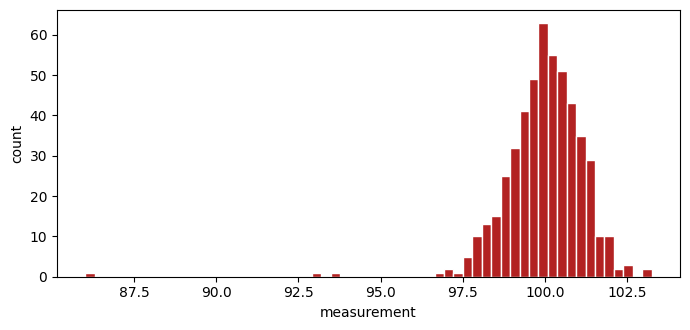

In [3]:
fig, ax = plt.subplots(figsize=(7, 3.4))
ax.hist(y_obs, bins=60, color="firebrick", edgecolor="white")
ax.set_xlabel("measurement")
ax.set_ylabel("count")
fig.tight_layout()
plt.show()

Almost all of the readings sit in a tight band. A handful are far away.

## The fitted model

Suppose we fit the model somehow and obtain $\hat\mu$ and $\hat\sigma$. It does not
matter for what follows how we got them.

In [4]:
mu_hat = y_obs.mean()
sigma_hat = np.sqrt(np.mean((y_obs - mu_hat) ** 2))   # MLE, divides by n
print(f"mu_hat = {mu_hat:.2f}, sigma_hat = {sigma_hat:.2f}   (good instrument SD = 1)")

mu_hat = 99.96, sigma_hat = 1.26   (good instrument SD = 1)


## Simulate and compare

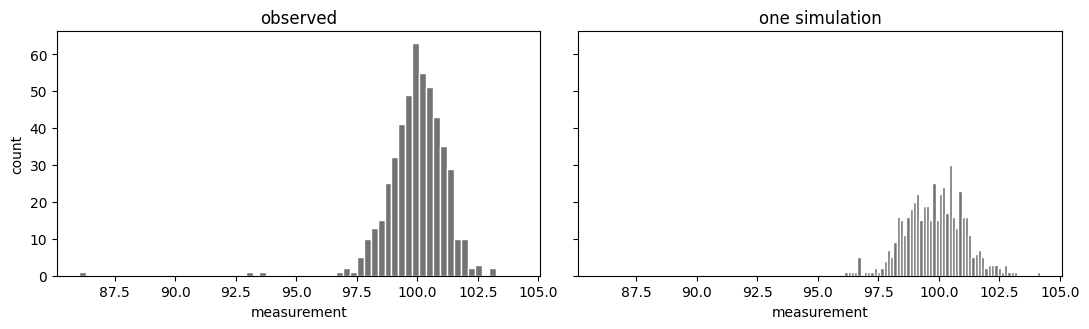

In [5]:
y_rep_one = rng.normal(mu_hat, sigma_hat, n_norm)

fig, axes = plt.subplots(1, 2, figsize=(11, 3.4), sharex=True, sharey=True)
for ax, (y, lab) in zip(axes, [(y_obs, "observed"), (y_rep_one, "one simulation")]):
    ax.hist(y, bins=60, color="0.45", edgecolor="white")
    ax.set_title(lab)
    ax.set_xlabel("measurement")
axes[0].set_ylabel("count")
fig.tight_layout()
plt.show()

Two things are wrong at once: the simulated bulk is too wide, and the simulated
data never produce a reading anywhere near the far ones.

## Another way to see this: Q-Q plot

Sort both datasets. Plot the $k$-th smallest simulated value against the $k$-th smallest
observed value, for every $k$. The dashed line is where simulated $=$ observed.

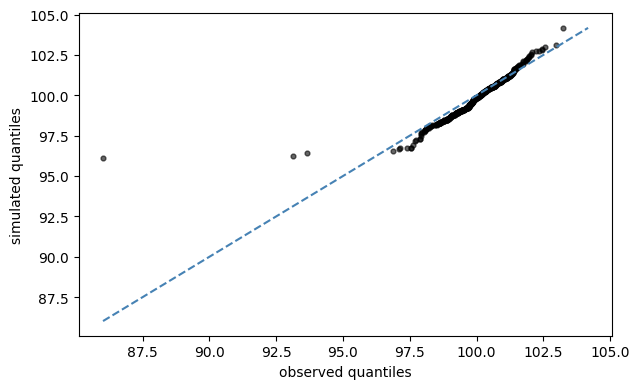

In [6]:
fig, ax = plt.subplots(figsize=(6.5, 4))
lims = [min(y_obs.min(), y_rep_one.min()), max(y_obs.max(), y_rep_one.max())]
ax.plot(lims, lims, color="steelblue", ls="--", lw=1.5)
ax.scatter(np.sort(y_obs), np.sort(y_rep_one), s=12, alpha=0.6, color="black")
ax.set_xlabel("observed quantiles")
ax.set_ylabel("simulated quantiles")
fig.tight_layout()
plt.show()

## Is that just one unlucky simulation?

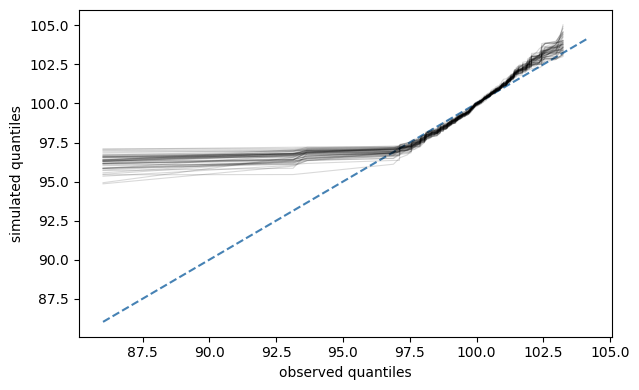

In [7]:
fig, ax = plt.subplots(figsize=(6.5, 4))
ax.plot(lims, lims, color="steelblue", ls="--", lw=1.5)
for _ in range(50):
    ax.plot(np.sort(y_obs), np.sort(rng.normal(mu_hat, sigma_hat, n_norm)),
            color="black", alpha=0.15, lw=0.8)
ax.set_xlabel("observed quantiles")
ax.set_ylabel("simulated quantiles")
fig.tight_layout()
plt.show()

## A one-number summary

How far from the middle is the most extreme reading?

$$
T(Y)=\max_i\left|Y_i-\operatorname{median}(Y)\right|.
$$

## The check in code

observed         = 14.0
replicate median = 4.0
p-value          = 0.0005


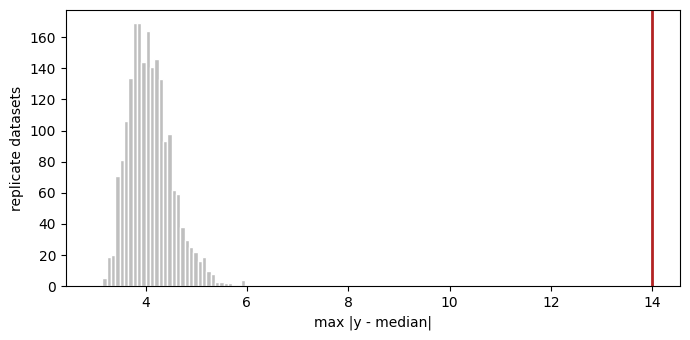

In [8]:
def outlier_distance(y):
    return np.max(np.abs(y - np.median(y)))


T_obs_tail = outlier_distance(y_obs)
T_rep_tail = np.array([outlier_distance(rng.normal(mu_hat, sigma_hat, n_norm))
                       for _ in range(B)])

print(f"observed         = {T_obs_tail:.1f}")
print(f"replicate median = {np.median(T_rep_tail):.1f}")
print(f"p-value          = {p_value(T_obs_tail, T_rep_tail):.4f}")

reference_plot(T_rep_tail, T_obs_tail, "max |y - median|")

The observed value is far outside anything the fitted model produces.

## What did this check tell us?

The failure is not evidence that $\mu$ or $\sigma$ was estimated imprecisely. Changing
$\mu$ moves the distribution and changing $\sigma$ stretches it. Neither lets a Normal
model produce a tight bulk *and* an occasional reading thirteen units away from the
middle.

# Section 2: Linear regression

## Reaction velocity and substrate concentration

The `Puromycin` data in R record reaction velocity at several substrate concentrations.
We use one treatment group and start with a linear model. R ships this dataset; the
values are given here directly.

intercept = 103.5, slope = 110.4, sigma_hat = 30.90


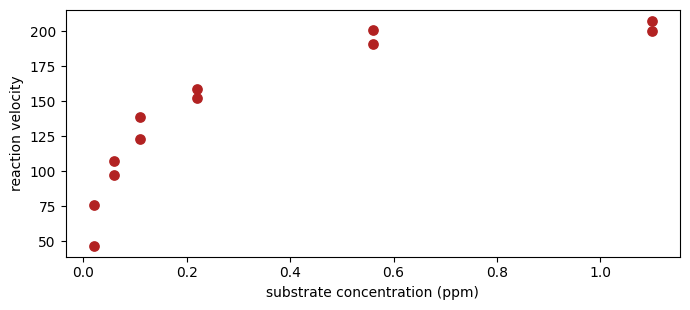

In [9]:
conc = np.array([0.02, 0.02, 0.06, 0.06, 0.11, 0.11,
                 0.22, 0.22, 0.56, 0.56, 1.10, 1.10])
rate = np.array([76, 47, 97, 107, 123, 139, 159, 152, 191, 201, 207, 200.0])
n_puro = len(conc)

slope, intercept = np.polyfit(conc, rate, 1)
fitted = intercept + slope * conc
resid_obs = rate - fitted

# residual standard error, with 2 estimated coefficients
sigma_lm = np.sqrt(np.sum(resid_obs ** 2) / (n_puro - 2))
print(f"intercept = {intercept:.1f}, slope = {slope:.1f}, sigma_hat = {sigma_lm:.2f}")

fig, ax = plt.subplots(figsize=(7, 3.2))
ax.scatter(conc, rate, color="firebrick", s=45)
ax.set_xlabel("substrate concentration (ppm)")
ax.set_ylabel("reaction velocity")
fig.tight_layout()
plt.show()

## The observed data

Velocity rises with concentration, steeply at first and then much less so.

## What experiment should we imitate?

The concentrations were part of the experimental design, so we hold them fixed. Each
replicate draws new responses at exactly the observed `conc` values.

In [10]:
def simulate_response():
    return rng.normal(fitted, sigma_lm)

## Simulate and compare

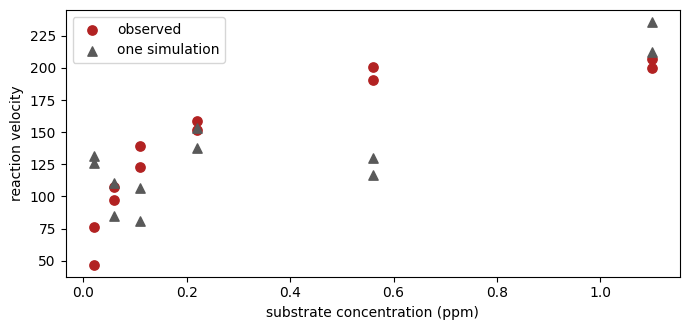

In [11]:
fig, ax = plt.subplots(figsize=(7, 3.4))
ax.scatter(conc, rate, color="firebrick", s=45, label="observed")
ax.scatter(conc, simulate_response(), color="0.35", s=45, marker="^",
           label="one simulation")
ax.set_xlabel("substrate concentration (ppm)")
ax.set_ylabel("reaction velocity")
ax.legend()
fig.tight_layout()
plt.show()

## Many simulations at once

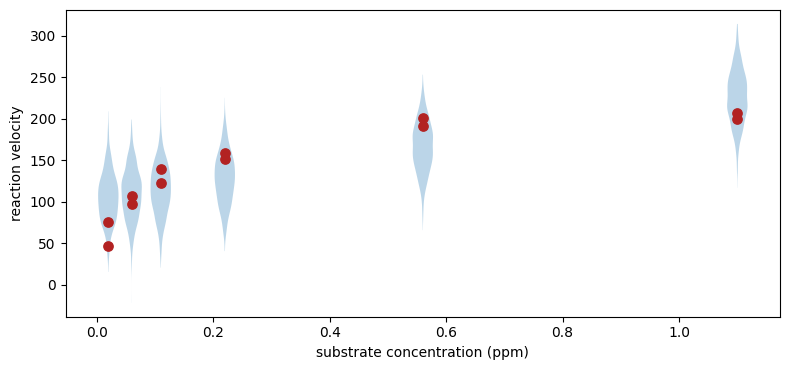

In [12]:
n_sim = 500
sim_by_conc = {c: [] for c in np.unique(conc)}
for _ in range(n_sim):
    y = simulate_response()
    for c in np.unique(conc):
        sim_by_conc[c].extend(y[conc == c])

fig, ax = plt.subplots(figsize=(8, 3.8))
positions = np.unique(conc)
ax.violinplot([sim_by_conc[c] for c in positions], positions=positions,
              widths=0.035, showextrema=False)
ax.scatter(conc, rate, color="firebrick", s=45, zorder=3)
ax.set_xlabel("substrate concentration (ppm)")
ax.set_ylabel("reaction velocity")
fig.tight_layout()
plt.show()

Each grey shape is the distribution of simulated velocities at that
concentration.

## Averaging the runs at each concentration

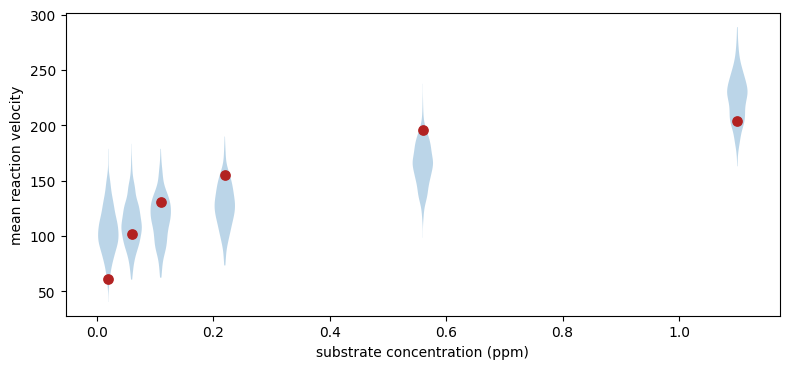

In [13]:
positions = np.unique(conc)
obs_mean = np.array([rate[conc == c].mean() for c in positions])

sim_mean = {c: [] for c in positions}
for _ in range(n_sim):
    y = simulate_response()
    for c in positions:
        sim_mean[c].append(y[conc == c].mean())

fig, ax = plt.subplots(figsize=(8, 3.8))
ax.violinplot([sim_mean[c] for c in positions], positions=positions,
              widths=0.035, showextrema=False)
ax.scatter(positions, obs_mean, color="firebrick", s=45, zorder=3)
ax.set_xlabel("substrate concentration (ppm)")
ax.set_ylabel("mean reaction velocity")
fig.tight_layout()
plt.show()

Each concentration was run twice and averaged, and the red dots are the average
of the observed data at each concentration.

## One potential discrepancy

Every concentration was run exactly twice, and so we can measure the amount of noise
using the absolute difference between the two observations at a given concentration.

$$
T(Y)=\sum_{\text{concentrations }c}\left|Y_{c,1}-Y_{c,2}\right|.
$$

## The pairs check in code

observed         = 79.0
replicate median = 205.2
p-value          = 0.0105


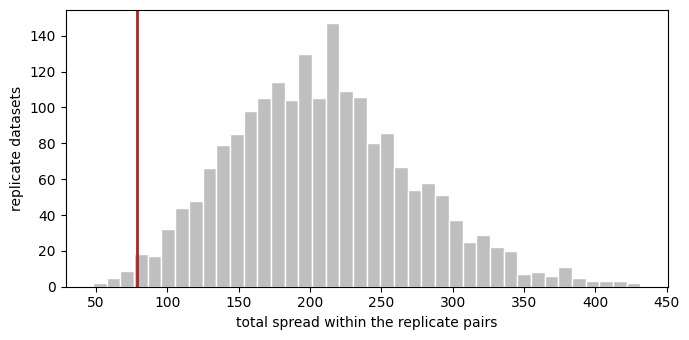

In [14]:
cs = np.unique(conc)


def pair_spread(y):
    return sum(abs(np.diff(y[conc == c])[0]) for c in cs)


T_obs_pairs = pair_spread(rate)
T_rep_pairs = np.array([pair_spread(simulate_response()) for _ in range(B)])

# Lack of fit can only inflate sigma_hat, so the direction is decided in
# advance: the observed pairs should agree *too well*.
p_lower = (1 + np.sum(T_rep_pairs <= T_obs_pairs)) / (B + 1)

print(f"observed         = {T_obs_pairs:.1f}")
print(f"replicate median = {np.median(T_rep_pairs):.1f}")
print(f"p-value          = {p_lower:.4f}")

reference_plot(T_rep_pairs, T_obs_pairs, "total spread within the replicate pairs")

The reason the model fails this check is that `sigma_hat` is doing two jobs:
covering the real noise, and absorbing the curvature the straight line cannot follow.
Comparing the two estimates of the noise directly:

In [15]:
pure_error_sd = np.sqrt(sum(np.diff(rate[conc == c])[0] ** 2 for c in cs) / (2 * len(cs)))
print(f"sigma_hat from the line = {sigma_lm:.2f}")
print(f"pure-error sd           = {pure_error_sd:.2f}")

sigma_hat from the line = 30.90
pure-error sd           = 10.78


## Two different ways to see one failure

The violin plots and this statistic detect the same defect in different ways:

* the violins show the true mean function bending where the line is straight;
* the pairs show the noise estimate inflated to cover that bend.

# Section 3: A single-server queue

## We have data and a fitted model

We observe one queue: the arrival times and the waiting times of a long run of
customers. Suppose we have fitted $\lambda$ and $\mu$ somehow. As before, how we
fitted them does not matter here.

In [16]:
def queue_from_durations(interarrival, service):
    n = len(interarrival)
    arrival = np.cumsum(interarrival)
    start = np.zeros(n)
    departure = np.zeros(n)
    for i in range(n):
        start[i] = arrival[i] if i == 0 else max(arrival[i], departure[i - 1])
        departure[i] = start[i] + service[i]
    return {"arrival": arrival, "service": service,
            "start": start, "departure": departure,
            "waiting": start - arrival}


def simulate_queue(n_customers, lam, mu):
    return queue_from_durations(rng.exponential(1 / lam, n_customers),
                                rng.exponential(1 / mu, n_customers))

In [17]:
n_cust = 1000
lambda_true = 0.50

slow = rng.binomial(1, 0.1, n_cust)
service_obs = np.where(slow == 1,
                       rng.exponential(4.6, n_cust),
                       rng.exponential(0.6, n_cust))
interarrival_obs = rng.exponential(1 / lambda_true, n_cust)
queue_obs = queue_from_durations(interarrival_obs, service_obs)

lambda_hat = 1 / interarrival_obs.mean()
mu_hat = 1 / service_obs.mean()
print(f"lambda_hat = {lambda_hat:.3f}, mu_hat = {mu_hat:.3f}, "
      f"rho = {lambda_hat / mu_hat:.3f}")
print(f"mean service time = {service_obs.mean():.2f}")

lambda_hat = 0.495, mu_hat = 1.032, rho = 0.479
mean service time = 0.97


## The observed waiting times

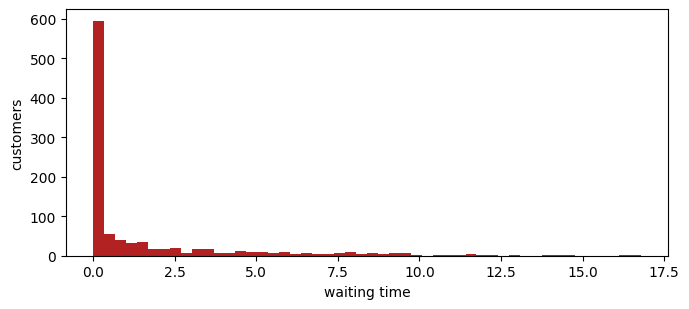

514 of 1000 customers never wait at all


In [18]:
fig, ax = plt.subplots(figsize=(7, 3.2))
ax.hist(queue_obs["waiting"], bins=50, color="firebrick")
ax.set_xlabel("waiting time")
ax.set_ylabel("customers")
fig.tight_layout()
plt.show()

print(f"{(queue_obs['waiting'] == 0).sum()} of {n_cust} customers never wait at all")

## Simulate and compare

Simulate one complete queue from the fitted model (same number of customers, same fitted
rates) and put its waiting times beside the observed ones.

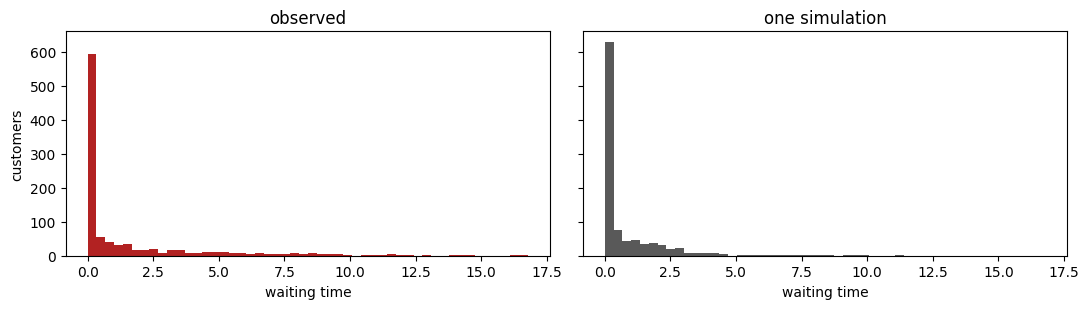

longest wait: observed 16.8, simulated 11.2


In [19]:
queue_rep_one = simulate_queue(n_cust, lambda_hat, mu_hat)

fig, axes = plt.subplots(1, 2, figsize=(11, 3.2), sharex=True, sharey=True)
hi = max(queue_obs["waiting"].max(), queue_rep_one["waiting"].max())
bins = np.linspace(0, hi, 51)
for ax, w, lab, col in zip(axes,
                           [queue_obs["waiting"], queue_rep_one["waiting"]],
                           ["observed", "one simulation"],
                           ["firebrick", "0.35"]):
    ax.hist(w, bins=bins, color=col)
    ax.set_title(lab)
    ax.set_xlabel("waiting time")
axes[0].set_ylabel("customers")
fig.tight_layout()
plt.show()

print(f"longest wait: observed {queue_obs['waiting'].max():.1f}, "
      f"simulated {queue_rep_one['waiting'].max():.1f}")

## The queue check in code

observed         = 1.52
replicate median = 0.87
p-value          = 0.0025


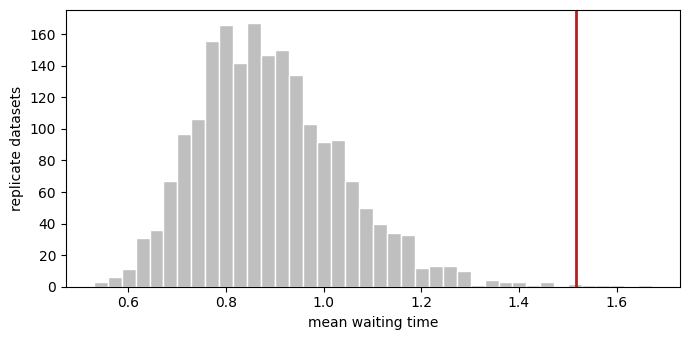

In [20]:
def mean_wait(q):
    return q["waiting"].mean()


T_obs_wait = mean_wait(queue_obs)
T_rep_wait = np.array([mean_wait(simulate_queue(n_cust, lambda_hat, mu_hat))
                       for _ in range(B)])

print(f"observed         = {T_obs_wait:.2f}")
print(f"replicate median = {np.median(T_rep_wait):.2f}")
print(f"p-value          = {p_value(T_obs_wait, T_rep_wait):.4f}")

reference_plot(T_rep_wait, T_obs_wait, "mean waiting time")

## What did this check tell us?

* Mainly that the model is insufficient to explain waiting times.
* You would need to know a bit more about the model and play around with other
  possibilities to see how to fix it.
* In this case, it could be fixed by modifying the service-time distribution (the data
  were actually generated under a model where arrivals were from an exponential
  distribution but service times were from a distribution with heavier tails).

# What we saw

* Uncertainty quantification and model checking answer different questions.
* A generative model makes predictions beyond the quantities used to fit it.
* We check those predictions by simulating complete datasets and calculating the same
  features in observed and replicated data.
* A failed check is most valuable when it points toward a specific weakness in the
  model and a plausible revision.